# Traditional ML Baselines (TF-IDF + Engineered Features)

This notebook trains and evaluates classic classifiers on **Sentiment140** (which we already preprocessed) using:
- **TF-IDF** on a cleaned text column (`text_clean`)
- Engineered numeric features: `neg_word_count`, `pos_word_count`, `avg_word_length`, `char_count`, `word_count`
- Models: Logistic Regression, Random Forest, Linear SVM (LinearSVC)

Outputs:
- Metrics table (Accuracy, weighted F1)
- Confusion matrices
- Saved model bundles (`joblib`) containing the model + preprocessing artifacts

## Mount you drive + Import Libraries

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

In [ ]:
DATA_PATH = "/content/drive/MyDrive/sentiment140-final-fixed.csv"

# Where to save models & results
SAVE_DIR = "/content/drive/MyDrive/traditional_ml_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Text + engineered feature columns
TEXT_COL = "text_clean"
NUMERIC_FEATURE_COLS = [
    "neg_word_count",
    "pos_word_count",
    "avg_word_length",
    "char_count",
    "word_count",
]

print("Data file:", DATA_PATH)
print("Save dir :", SAVE_DIR)

Data file: /content/drive/MyDrive/sentiment140-final-fixed.csv
Save dir : /content/drive/MyDrive/traditional_ml_models


## Load the preprocessed data and build Target

In [ ]:
df = pd.read_csv(DATA_PATH)
print("df shape:", df.shape)
print("Columns:", df.columns.tolist())

# Helper to print distributions if column exists
def show_col_counts(df, col):
    if col in df.columns:
        print(f"\n--- {col} value_counts() ---")
        print(df[col].value_counts())
    else:
        print(f"\n(No column named '{col}' found.)")

show_col_counts(df, "target")
show_col_counts(df, "label_str")
show_col_counts(df, "sentiment")

# ------------------------------------------------------------
# 2.1 Decide how to create the column 'target_binary'
# ------------------------------------------------------------

target_col = None

# Case A: If 'target' exists with >= 2 classes, use it directly
if "target" in df.columns and df["target"].nunique() >= 2:
    target_col = "target"
    df["target_binary"] = df["target"].astype(int)
    print("\n✅ Using existing 'target' as 'target_binary'.")

# Case B: If 'label_str' exists and looks like negative/positive, map to 0/1
elif "label_str" in df.columns and df["label_str"].nunique() >= 2:
    print("\n⚠️ 'target' unusable; trying to map 'label_str' -> binary target.")
    print(df["label_str"].value_counts())

    # Adjust mapping to your actual strings
    mapping = {
        "negative": 0,
        "positive": 1,
        "0": 0,
        "1": 1,
        "4": 1,  # if you encoded Sentiment140 4 -> positive
    }

    df["target_binary"] = df["label_str"].map(mapping)
    df = df[df["target_binary"].notna()].copy()
    df["target_binary"] = df["target_binary"].astype(int)
    target_col = "target_binary"
    print("\n Built 'target_binary' from 'label_str'.")

# Case C: If 'sentiment' exists with {0,4}, map to 0/1
elif "sentiment" in df.columns and df["sentiment"].nunique() >= 2:
    print("\n⚠️ 'target'/'label_str' unusable; using 'sentiment' (0/4) -> 0/1.")
    print(df["sentiment"].value_counts())
    df["target_binary"] = df["sentiment"].map({0: 0, 4: 1})
    df = df[df["target_binary"].notna()].copy()
    df["target_binary"] = df["target_binary"].astype(int)
    target_col = "target_binary"
    print("\n Built 'target_binary' from 'sentiment'.")

else:
    raise ValueError(
        " Could not find a usable label column with at least 2 classes.\n"
        "Check your CSV: it may truly contain only one class now.\n"
        "Look for something like 'sentiment', 'polarity', or 'label_str' with 2+ values."
    )

print("\nFinal target column:", target_col)
print("target_binary distribution:\n", df["target_binary"].value_counts())

df shape: (1593001, 14)
Columns: ['target', 'label_str', 'id', 'date', 'flag', 'user', 'text', 'text_clean', 'sentiment_score_norm', 'neg_word_count', 'pos_word_count', 'avg_word_length', 'char_count', 'word_count']

--- target value_counts() ---
target
0    796896
4    796105
Name: count, dtype: int64

--- label_str value_counts() ---
label_str
negative    796896
positive    796105
Name: count, dtype: int64

(No column named 'sentiment' found.)

✅ Using existing 'target' as 'target_binary'.

Final target column: target
target_binary distribution:
 target_binary
0    796896
4    796105
Name: count, dtype: int64


## Select Features and Drop Null Values

In [ ]:

cols_needed = [TEXT_COL] + NUMERIC_FEATURE_COLS + ["target_binary"]
missing_cols = [c for c in cols_needed if c not in df.columns]
if missing_cols:
    raise ValueError(f"❌ Missing columns in df: {missing_cols}")

df = df[cols_needed].dropna(subset=[TEXT_COL, "target_binary"]).copy()

print("Shape after selecting columns & dropping NAs:", df.shape)
print("\nFinal target distribution:", df["target_binary"].value_counts())

Shape after selecting columns & dropping NAs: (1593001, 7)

Final target distribution: target_binary
0    796896
4    796105
Name: count, dtype: int64


## Train / Test Split

In [ ]:

X = df[[TEXT_COL] + NUMERIC_FEATURE_COLS]
y = df["target_binary"]

print("Full y distribution:", np.unique(y, return_counts=True))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # keep class balance
)

print("\ny_train distribution:", np.unique(y_train, return_counts=True))
print("y_test distribution:", np.unique(y_test, return_counts=True))

Full y distribution: (array([0, 4]), array([796896, 796105]))

y_train distribution: (array([0, 4]), array([637516, 636884]))
y_test distribution: (array([0, 4]), array([159380, 159221]))


## TF-IDF Vectorization on Text

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    lowercase=True,
)

X_train_text = vectorizer.fit_transform(X_train[TEXT_COL].fillna(""))
X_test_text  = vectorizer.transform(X_test[TEXT_COL].fillna(""))

print("X_train_text shape:", X_train_text.shape)
print("X_test_text shape :", X_test_text.shape)

X_train_text shape: (1274400, 20000)
X_test_text shape : (318601, 20000)


## Scale the Numeric Features & Combine them

In [ ]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[NUMERIC_FEATURE_COLS].fillna(0))
X_test_num  = scaler.transform(X_test[NUMERIC_FEATURE_COLS].fillna(0))

X_train_final = hstack([X_train_text, csr_matrix(X_train_num)])
X_test_final  = hstack([X_test_text, csr_matrix(X_test_num)])

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape :", X_test_final.shape)

X_train_final shape: (1274400, 20005)
X_test_final shape : (318601, 20005)


## Logistic Regression Model

In [ ]:
results_list = []

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_final, y_train)

lr_preds = lr.predict(X_test_final)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average="weighted")

print("📌 Logistic Regression (Text + Engineered Features)")
print("Accuracy:", lr_acc)
print("F1 Score:", lr_f1)
print("\nClassification Report:\n", classification_report(y_test, lr_preds))

results_list.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_acc,
    "F1_weighted": lr_f1,
})

📌 Logistic Regression (Text + Engineered Features)
Accuracy: 0.8133496128386288
F1 Score: 0.8133282967760974

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81    159380
           4       0.81      0.82      0.82    159221

    accuracy                           0.81    318601
   macro avg       0.81      0.81      0.81    318601
weighted avg       0.81      0.81      0.81    318601



## Random Forest Model

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_final, y_train)
rf_preds = rf.predict(X_test_final)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds, average="weighted")

print("📌 Random Forest (Text + Engineered Features)")
print("Accuracy:", rf_acc)
print("F1 Score:", rf_f1)
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

results_list.append({
    "Model": "Random Forest",
    "Accuracy": rf_acc,
    "F1_weighted": rf_f1,
})

📌 Random Forest (Text + Engineered Features)
Accuracy: 0.7917865920069302
F1 Score: 0.7917457486624694

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79    159380
           4       0.80      0.78      0.79    159221

    accuracy                           0.79    318601
   macro avg       0.79      0.79      0.79    318601
weighted avg       0.79      0.79      0.79    318601



## Linear Support Vector Machine Model

In [ ]:
svm = LinearSVC()
svm.fit(X_train_final, y_train)

svm_preds = svm.predict(X_test_final)

svm_acc = accuracy_score(y_test, svm_preds)
svm_f1  = f1_score(y_test, svm_preds, average="weighted")

print("📌 Linear SVM (Text + Engineered Features)")
print("Accuracy:", svm_acc)
print("F1 Score:", svm_f1)
print("\nClassification Report:\n", classification_report(y_test, svm_preds))

results_list.append({
    "Model": "Linear SVM",
    "Accuracy": svm_acc,
    "F1_weighted": svm_f1,
})

📌 Linear SVM (Text + Engineered Features)
Accuracy: 0.8122981409348997
F1 Score: 0.8122583928702942

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81    159380
           4       0.80      0.83      0.81    159221

    accuracy                           0.81    318601
   macro avg       0.81      0.81      0.81    318601
weighted avg       0.81      0.81      0.81    318601



## Summary Table of all of our Models

In [ ]:

results_df = pd.DataFrame(results_list)
results_df

,Model,Accuracy,F1_weighted
0,Logistic Regression,0.813350,0.813328
1,Random Forest,0.791787,0.791746
2,Linear SVM,0.812298,0.812258


## Confusion Matrices

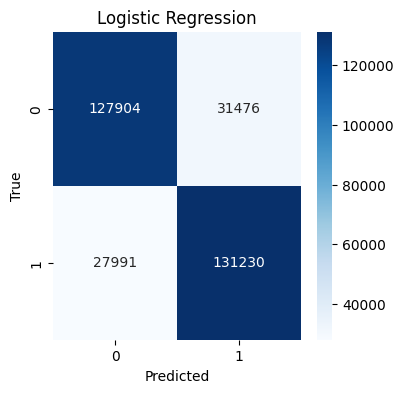

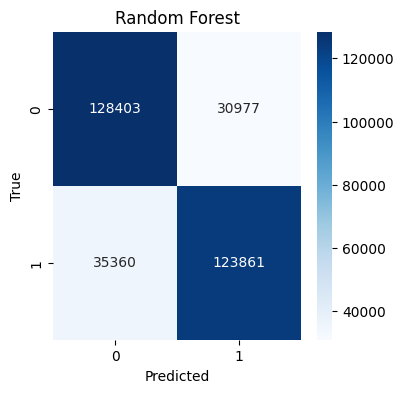

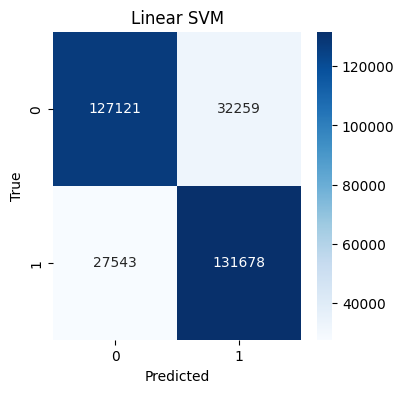

In [ ]:
def plot_conf_mat(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_conf_mat(y_test, lr_preds,  "Logistic Regression")
plot_conf_mat(y_test, rf_preds,  "Random Forest")
plot_conf_mat(y_test, svm_preds, "Linear SVM")

## Save Results and Models to Drive for Future Use

In [ ]:
results_path = f"{SAVE_DIR}/trad_ml_results.csv"
results_df.to_csv(results_path, index=False)
print(f" Saved metrics to {results_path}")

# Pack preprocessing + model objects together
lr_bundle = {
    "text_col": TEXT_COL,
    "num_feature_cols": NUMERIC_FEATURE_COLS,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "model": lr,
}

rf_bundle = {
    "text_col": TEXT_COL,
    "num_feature_cols": NUMERIC_FEATURE_COLS,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "model": rf,
}

svm_bundle = {
    "text_col": TEXT_COL,
    "num_feature_cols": NUMERIC_FEATURE_COLS,
    "vectorizer": vectorizer,
    "scaler": scaler,
    "model": svm,
}

joblib.dump(lr_bundle,  f"{SAVE_DIR}/model_lr_text_num.joblib")
joblib.dump(svm_bundle, f"{SAVE_DIR}/model_svm_text_num.joblib")

print("\n Saved models to:")
print(f"   {SAVE_DIR}/model_lr_text_num.joblib")
print(f"   {SAVE_DIR}/model_rf_text_num.joblib")
print(f"   {SAVE_DIR}/model_svm_text_num.joblib")

 Saved metrics to /content/drive/MyDrive/traditional_ml_models/trad_ml_results.csv

 Saved models to:
   /content/drive/MyDrive/traditional_ml_models/model_lr_text_num.joblib
   /content/drive/MyDrive/traditional_ml_models/model_rf_text_num.joblib
   /content/drive/MyDrive/traditional_ml_models/model_svm_text_num.joblib
